In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib qt

import torch
from IPython.display import display, clear_output
import torch.nn as nn

from keras.datasets import cifar10
from tqdm.notebook import tqdm
import torch.nn.functional as F

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print (x_train.shape, y_train.shape)
print (x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [ ]:
def softmax(X):
    """
    Apply the softmax function to convert logits to probabilities.

    Parameters:
    X (numpy.ndarray): Input array of shape (n_samples, n_classes).

    Returns:
    numpy.ndarray: Output array of the same shape as input, where each row represents a probability distribution.
    """
    X_stable = X - np.max(X, axis=1, keepdims=True)
    s = np.exp(X_stable)
    total = np.sum(s, axis=1).reshape(-1, 1)
    return s / total


In [4]:
from turtle import forward
from regex import D
from scipy.signal import correlate2d

class Layer:
    def __init__(self, learning_rate=0.001, l2_lambda=0.0):
        self.learing_rate = learning_rate
        # Cache for bakpropagation
        self.cache = {}
        # Storage for gradients. Used to update weights.
        self.weight_grads = []
        self.l2_lambda = l2_lambda
        
        # Monitoring variables for debugging and analysis
        self.monitoring = {}
        self.monitoring['weight_grads_history'] = []
        self.monitoring['weights_history'] = []
    
    def _update_monitoring(self, key, monitored_value):
        item = []
        for val in monitored_value:
            item.append({'Min': np.min(val),
                         'Max': np.max(val),
                         'Norm': np.linalg.norm(val)})
        self.monitoring[key].append(item)
        
    def forward(self, x):
        raise NotImplementedError("Please Implement this method")
    
    def backward(self, grad):
        grad, weight_grads = self._backward_internal(grad)
        self.weight_grads = weight_grads
        self._update_monitoring('weight_grads_history', weight_grads)
        self._update_weights()
        # Return the gradient to the previous layer
        return grad
    
    def get_loss(self):
        loss = 0
        weights = self._get_weights()
        self._update_monitoring('weights_history', weights)
        
        # Add L2 regularization loss
        loss += 0.5 * self.l2_lambda * sum([np.sum(w**2) for w in weights])
        return loss
        
    def _get_weights(self):
        return []
    
    def _backward_internal(self, grad):
        '''
        Compute the gradient of the loss with respect to the input of this layer.
        Returns the gradient to be passed to the previous layer.
        Returns gradient of weights and biases.
        '''
        raise NotImplementedError("Please Implement this method")
    
    def _update_weights(self, beta1=0.9, beta2=0.999, eps=1e-8):
        weights = list(self._get_weights())
        if len(weights) == 0:
            return
        # Update weights using Adam optimizer
        if not hasattr(self, 'm'):
            self.m = [np.zeros_like(w) for w in weights]
            self.v = [np.zeros_like(w) for w in weights]
            self.t = 0
        
        self.t += 1
        lr_t = self.learing_rate * np.sqrt(1 - beta2 ** self.t) / (1 - beta1 ** self.t)
        
        # Update weights.
        for i in range(len(weights)):
            self.m[i] = beta1 * self.m[i] + (1 - beta1) * self.weight_grads[i]
            self.v[i] = beta2 * self.v[i] + (1 - beta2) * (self.weight_grads[i] ** 2)
            weights[i] -= lr_t * self.m[i] / (np.sqrt(self.v[i]) + eps)
            

class LinearLayer(Layer):
    def __init__(self, output_shape, learning_rate=0.001, l2_lambda=0.0):
        super().__init__(learning_rate, l2_lambda)
        self.output_shape = output_shape

    def _setup(self, x):
        # Initialize weights and biases
        input_shape = np.prod(x.shape[1:])
        self.W = np.random.randn(input_shape, self.output_shape) * np.sqrt(2 / input_shape)
        self.b = np.zeros(self.output_shape)
    
    def forward(self, x):
        if not hasattr(self, 'W'):
            self._setup(x)
        # Store input for backpropagation
        self.cache['input'] = x
        return x @ self.W + self.b
    
    def _backward_internal(self, grad):
        # Compute gradients for weights and biases
        # Add a term for the derivative of l2 regularization
        DL_dW = self.cache['input'].T @ grad + self.l2_lambda * self.W
        DL_db = np.mean(grad, axis=0)
        return grad @ self.W.T, [DL_dW, DL_db]
    
    def _get_weights(self):
        return self.W, self.b
    

class ReLU(Layer):
    def __init__(self, alpha=0.01):
        super().__init__()
        self.alpha = alpha
        
    def forward(self, x):
        self.cache['input'] = x
        return self._leaky_relu(x)
    
    def _leaky_relu(self, x):
        return np.where(x > 0, x, self.alpha * x)
    
    def _backward_internal(self, grad):
        return grad * (np.where(self.cache['input'] > 0, 1, self.alpha)).astype(np.float32), []


class FlattenLayer(Layer):
    def __init__(self):
        super().__init__()
        self.input_shape = None
    
    def forward(self, x):
        self.input_shape = x.shape
        return x.reshape((self.input_shape[0], -1))
    
    def _backward_internal(self, grad):
        return grad.reshape(self.input_shape), []
        
    
class ConvolutionLayer(Layer):
    def __init__(self, filter_shape, num_filters, pad_width=0, learning_rate=0.001, l2_lambda=0.0):
        super().__init__(learning_rate, l2_lambda)
        self.filter_shape = filter_shape
        self.num_filters = num_filters
        self.l2_lambda = l2_lambda
        self.pad_width = pad_width
    
    def _setup(self, x):
        self.image_shape = x[0].shape
        self.num_image_channels = self.image_shape[2]
        self.filter_shape = (*self.filter_shape, self.num_image_channels)
        self.filter_weights = np.random.randn(self.num_filters, *self.filter_shape) *\
            np.sqrt(2 / (np.prod(self.filter_shape)))
        self.filter_bias = np.zeros((self.num_filters, 1))
        
    def get_output_shape(self):
        return (self.image_shape[0] - self.filter_shape[0] + 1,
                self.image_shape[1] - self.filter_shape[1] + 1,
                self.num_filters)
        
    def _convolve(self, input):
        if not hasattr(self, 'filter_weights'):
            self._setup(input)
            
        N, H, W, num_channels = input.shape
        num_filters, H_filter, W_filter, _ = self.filter_weights.shape
        H_out = H - H_filter + 1
        W_out = W - W_filter + 1

        # Extract patches using sliding window
        patches = np.lib.stride_tricks.sliding_window_view(
            input, (H_filter, W_filter), axis=(1, 2))
        patches = patches.reshape(N, H_out, W_out, -1)
        filters = self.filter_weights.reshape(num_filters, -1)

        # Convolve using einsum
        conv_out = np.einsum('nhwc,fc->nfhw', patches, filters)
        conv_out = np.transpose(conv_out, (0, 2, 3, 1))
        
        # Add bias, ensuring proper broadcasting
        conv_out += self.filter_bias.reshape(1, 1, 1, num_filters)

        # Cache the input for backpropagation
        self.cache['convolve_input'] = input
        return conv_out
    
    def forward(self, x):
        pad_x = np.pad(
            x, 
            pad_width=((0, 0), 
                       (self.pad_width, self.pad_width),
                       (self.pad_width, self.pad_width), 
                       (0, 0)), 
            mode='constant', 
            constant_values=0)
        return self._convolve(pad_x)
    
    def _backward_internal(self, grad):
        dL_filter_weights = np.zeros_like(self.filter_weights)
        dL_filter_bias = np.zeros_like(self.filter_bias)

        input = self.cache['convolve_input']
        for i in range(input.shape[0]):
            for j in range(self.num_filters):
                for c in range(self.num_image_channels):
                    dL_filter_weights[j, :, :, c] += correlate2d(
                        input[i, :, :, c], grad[i, :, :, j], mode='valid')
                dL_filter_bias[j] += np.sum(grad[i, :, :, j])
        
        # Add term for gradient of L2 regularization
        dL_filter_weights += self.l2_lambda * self.filter_weights
        
        dL_input = self._grad_input_conv(grad)
        return dL_input, [dL_filter_weights, dL_filter_bias]
    
    def _grad_input_conv(self, grad):
        input = self.cache['convolve_input']
        N, H, W, C_in = input.shape
        F, KH, KW, _ = self.filter_weights.shape
        dX = np.zeros(input.shape)

        for n in range(N):
            for c in range(C_in):
                for f in range(F):
                    flipped_filter = np.rot90(self.filter_weights[f, :, :, c], 2)
                    dX[n, :, :, c] += correlate2d(grad[n, :, :, f], flipped_filter, mode='full')
        if self.pad_width > 0:
            dX = dX[:, self.pad_width:-self.pad_width, self.pad_width:-self.pad_width, :]
        return dX

    def _get_weights(self):
        return self.filter_weights, self.filter_bias


class MaxPool(Layer):
    def __init__(self, pool_size=2, stride=2):
        super().__init__()
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        x_tensor = x_tensor.permute(0, 3, 1, 2)  # NHWC -> NCHW
        self.cache['x_tensor_shape'] = x_tensor.shape

        out_tensor, self.cache['indices'] = F.max_pool2d(
            x_tensor,
            kernel_size=self.pool_size,
            stride=self.stride,
            return_indices=True
        )
        
        out = out_tensor.permute(0, 2, 3, 1).numpy()  # NCHW -> NHWC
        return out

    def _backward_internal(self, grad):
        grad_tensor = torch.tensor(grad, dtype=torch.float32).permute(0, 3, 1, 2)  # NHWC -> NCHW
        dx_tensor = F.max_unpool2d(
            grad_tensor,
            self.cache['indices'],
            kernel_size=self.pool_size,
            stride=self.stride,
            output_size=self.cache['x_tensor_shape']
        )
        dx = dx_tensor.permute(0, 2, 3, 1).numpy()  # NCHW -> NHWC
        return dx, []


class BatchNormLayer(Layer):
    def __init__(self, num_features, learning_rate=0.001):
        super().__init__(learning_rate)
        self.bn = nn.BatchNorm2d(num_features=num_features, eps=1e-5, momentum=0.9, affine=True, track_running_stats=True)
        self.bn.train(True)

    def forward(self, x):
        # Input: (N, H, W, C) → PyTorch expects: (N, C, H, W)
        x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
        x_tensor.requires_grad_(True)
        self.cache['x_tensor'] = x_tensor  # Store for backward
        out = self.bn(x_tensor)
        return out.permute(0, 2, 3, 1).detach().numpy()

    def _backward_internal(self, grad):
        # Convert grad to PyTorch tensor and match shape (N, C, H, W)
        grad_tensor = torch.tensor(grad, dtype=torch.float32).permute(0, 3, 1, 2)
        x_tensor = self.cache['x_tensor']

        # Use PyTorch's autograd to compute gradients
        if x_tensor.grad is not None:
            x_tensor.grad.zero_()

        out = self.bn(x_tensor)
        out.backward(grad_tensor)

        dx = x_tensor.grad
        if dx is None:
            raise RuntimeError("Gradient computation failed: x_tensor.grad is None")

        dx = dx.permute(0, 2, 3, 1).detach().numpy()
        dgamma = self.bn.weight.grad.detach().numpy()
        dbeta = self.bn.bias.grad.detach().numpy()

        return dx, [dgamma, dbeta]

    def _get_weights(self):
        return [self.bn.weight.detach().numpy(), self.bn.bias.detach().numpy()]

In [5]:
class TrainingMonitor:
    def __init__(self, layers):
        self.layers = layers
        self.batch_indices = []
        self.accuracies = []
        self.losses = []

        self.plot_layers = [
            (i, l) for i, l in enumerate(self.layers)
            if l._get_weights() and 'weights_history' in l.monitoring and 'weight_grads_history' in l.monitoring
        ]

        # Set up monitoring figure with 2 columns: one for weights, one for gradients
        self.fig_monitoring, self.axs_monitoring = plt.subplots(
            len(self.plot_layers), 2, figsize=(12, 4 * len(self.plot_layers)), squeeze=False
        )

        # Accuracy and loss chart
        plt.ion()
        self.fig_acc, self.ax_acc = plt.subplots(figsize=(8, 4))
        self.acc_line, = self.ax_acc.plot([], [], label='Accuracy')
        self.loss_line, = self.ax_acc.plot([], [], label='Loss')
        self.ax_acc.set_xlabel('Batch')
        self.ax_acc.set_ylabel('Value')
        self.ax_acc.set_title('Accuracy and Loss')
        self.ax_acc.legend()
        self.ax_acc.grid(True)

    def update(self, batch_idx, acc, loss):
        self.batch_indices.append(batch_idx)
        self.accuracies.append(acc)
        self.losses.append(loss)

        # Update accuracy/loss chart
        self.acc_line.set_data(self.batch_indices, self.accuracies)
        self.loss_line.set_data(self.batch_indices, self.losses)
        self.ax_acc.relim()
        self.ax_acc.autoscale_view()
        self.fig_acc.canvas.draw()
        self.fig_acc.canvas.flush_events()

        for row_idx, (i, layer) in enumerate(self.plot_layers):
            ax_w = self.axs_monitoring[row_idx][0]
            ax_g = self.axs_monitoring[row_idx][1]

            ax_w.clear()
            ax_g.clear()

            for j in range(len(layer.monitoring['weights_history'][0])):
                w_mins = [entry[j]['Min'] for entry in layer.monitoring['weights_history']]
                w_maxs = [entry[j]['Max'] for entry in layer.monitoring['weights_history']]
                w_norms = [entry[j]['Norm'] for entry in layer.monitoring['weights_history']]
                ax_w.plot(self.batch_indices[:len(w_mins)], w_mins, label=f'W{j} Min')
                ax_w.plot(self.batch_indices[:len(w_maxs)], w_maxs, label=f'W{j} Max')
                ax_w.plot(self.batch_indices[:len(w_norms)], w_norms, label=f'W{j} Norm')

                g_mins = [entry[j]['Min'] for entry in layer.monitoring['weight_grads_history']]
                g_maxs = [entry[j]['Max'] for entry in layer.monitoring['weight_grads_history']]
                g_norms = [entry[j]['Norm'] for entry in layer.monitoring['weight_grads_history']]
                ax_g.plot(self.batch_indices[:len(g_mins)], g_mins, label=f'G{j} Min')
                ax_g.plot(self.batch_indices[:len(g_maxs)], g_maxs, label=f'G{j} Max')
                ax_g.plot(self.batch_indices[:len(g_norms)], g_norms, label=f'G{j} Norm')

            ax_w.set_title(f'{i} {layer.__class__.__name__} Weights')
            ax_w.set_xlabel('Batch')
            ax_w.set_ylabel('Value')
            ax_w.legend()
            ax_w.grid(True)

            ax_g.set_title(f'{i} {layer.__class__.__name__} Gradients')
            ax_g.set_xlabel('Batch')
            ax_g.set_ylabel('Value')
            ax_g.legend()
            ax_g.grid(True)

        self.fig_monitoring.tight_layout()
        self.fig_monitoring.canvas.draw()
        self.fig_monitoring.canvas.flush_events()

In [6]:
class CNN:
    def __init__(self, num_classes=10, l2_lambda=0.0):
        self.num_classes = num_classes
        self.layers = []
        self.loss = None
        self.l2_lambda = l2_lambda
        self.cache = {}
        self.debug_once = True
    
    def reset(self):
        self.loss = None
        self.l2_lambda = 0.0
        self.cache = {}
        
    def setup_architecture(self, learning_rate, l2_lambda):
        conv1 = ConvolutionLayer(
            (5, 5), 16, pad_width=2, learning_rate=learning_rate, l2_lambda=self.l2_lambda)
        conv2 = ConvolutionLayer(
            (5, 5), 20, pad_width=2, learning_rate=learning_rate, l2_lambda=self.l2_lambda)
        conv3 = ConvolutionLayer(
            (5, 5), 20, pad_width=2, learning_rate=learning_rate, l2_lambda=self.l2_lambda)
        self.layers = [
            conv1,
            BatchNormLayer(16),
            ReLU(),
            MaxPool(),   # ↓ downsampling
            conv2,
            BatchNormLayer(20),
            ReLU(),
            MaxPool(),   # ↓ downsampling
            conv3,
            BatchNormLayer(20),
            ReLU(),
            MaxPool(),   # ↓ downsampling
            FlattenLayer(),
            LinearLayer(self.num_classes, learning_rate=learning_rate, l2_lambda=self.l2_lambda),
        ]
        
    def forward(self, x, y):
        for layer in self.layers:
            out = layer.forward(x)
            if self.debug_once:
                print(f"Layer: {layer.__class__.__name__:>20} \
                    {str(x.shape):>20} -> {str(out.shape):<}")
            x = out
            
        probs = softmax(x)
        self.cache['softmax_output'] = probs
        
        loss = np.mean(-np.log(probs[np.arange(x.shape[0]), y.flatten()] + 1e-10))
        l2_loss = sum([layer.get_loss() for layer in self.layers])
        loss += l2_loss
        accuracy = np.mean(np.argmax(probs, axis=1) == y.flatten()) * 100
        return probs, accuracy, loss
    
    def backward(self, y):
        if self.debug_once:
            print(f"\nBackpropagation...")
        y_onehot = (y[:, np.newaxis] == np.arange(self.num_classes)).astype(np.float32)
        grad = self.cache['softmax_output'] - y_onehot
        
        for layer in reversed(self.layers):
            grad_in = layer.backward(grad)
            if self.debug_once:
                print(f"Layer: {layer.__class__.__name__:>20} \
                    Grad {str(grad.shape):>20} -> {str(grad_in.shape):<}")
            grad = grad_in
        
    def train(self, x_train, y_train, epochs=10, batch_size=64, learning_rate=0.001, l2_lambda=0.01):
        self.reset()
        self.setup_architecture(learning_rate=learning_rate, l2_lambda=l2_lambda)
        
        y_train = y_train.flatten()
        accuracies = []
        losses = []

        monitor = None

        for epoch in tqdm(range(epochs), desc="Epochs"):
            indices = np.arange(x_train.shape[0])
            np.random.shuffle(indices)
            x_train, y_train = x_train[indices], y_train[indices]
            
            epoch_loss, epoch_acc, count = 0, 0, 0
            for i in tqdm(range(0, x_train.shape[0], batch_size), leave=False, desc=f"Batches in Epoch {epoch+1}"):
                xb = x_train[i:i+batch_size]
                yb = y_train[i:i+batch_size]

                probs, acc, loss = self.forward(xb, yb)
                
                self.backward(yb)
                self.debug_once = False

                if monitor is None:
                    monitor = TrainingMonitor(self.layers)
                    
                epoch_loss += loss
                epoch_acc += acc
                count += 1
                
                batch_idx = epoch * (x_train.shape[0] // batch_size) + i // batch_size
                monitor.update(batch_idx, acc, loss)
                
            accuracies.append(epoch_acc/count)
            losses.append(epoch_loss/count)
            print(f"Epoch {epoch+1}: Accuracy={epoch_acc/count:.2f}% | Loss={epoch_loss/count:.4f}")

            # Early stopping if accuracy doesn't improve over last N epochs
            early_stop_window = 5
            min_delta = 0.1  # minimum required improvement

            if len(accuracies) >= early_stop_window:
                recent_accs = accuracies[-early_stop_window:]
                if max(recent_accs) - min(recent_accs) < min_delta:
                    print(f"🛑 Early stopping: accuracy flat in last {early_stop_window} epochs")
                    break

        
model = CNN(num_classes=10)
X = x_train[:2800]
y = y_train[:2800]
model.train(X, y, epochs=25, batch_size=64, learning_rate=0.002, l2_lambda=0.01)

Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

Batches in Epoch 1:   0%|          | 0/44 [00:00<?, ?it/s]

Layer:     ConvolutionLayer                          (64, 32, 32, 3) -> (64, 32, 32, 16)
Layer:       BatchNormLayer                         (64, 32, 32, 16) -> (64, 32, 32, 16)
Layer:                 ReLU                         (64, 32, 32, 16) -> (64, 32, 32, 16)
Layer:              MaxPool                         (64, 32, 32, 16) -> (64, 16, 16, 16)
Layer:     ConvolutionLayer                         (64, 16, 16, 16) -> (64, 16, 16, 20)
Layer:       BatchNormLayer                         (64, 16, 16, 20) -> (64, 16, 16, 20)
Layer:                 ReLU                         (64, 16, 16, 20) -> (64, 16, 16, 20)
Layer:              MaxPool                         (64, 16, 16, 20) -> (64, 8, 8, 20)
Layer:     ConvolutionLayer                           (64, 8, 8, 20) -> (64, 8, 8, 20)
Layer:       BatchNormLayer                           (64, 8, 8, 20) -> (64, 8, 8, 20)
Layer:                 ReLU                           (64, 8, 8, 20) -> (64, 8, 8, 20)
Layer:              MaxPool  

KeyboardInterrupt: 

Test Accuracy: 25.51%
Test Loss: 17.0750


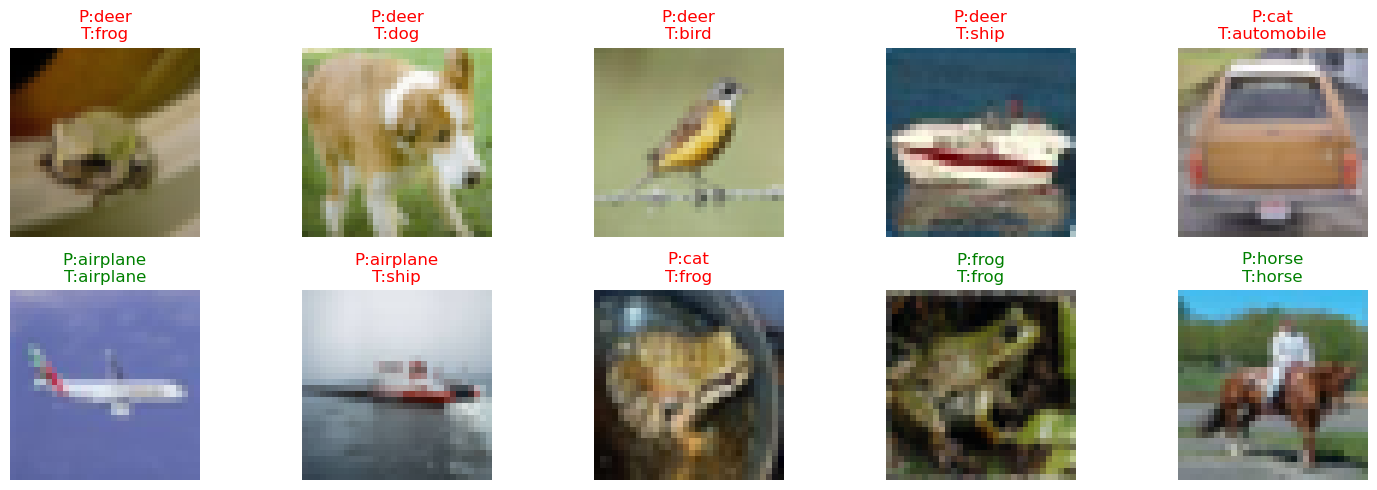

In [ ]:
import matplotlib.pyplot as plt

def evaluate_and_visualize(model, x_test, y_test, class_names, sample_count=10):
    # Evaluate full test accuracy/loss
    probs, acc, loss = model.forward(x_test, y_test)
    print(f"Test Accuracy: {acc:.2f}%")
    print(f"Test Loss: {loss:.4f}")
     # Predict classes for a few samples
    indices = np.random.choice(x_test.shape[0], sample_count, replace=False)
    x_sample = x_test[indices]
    y_sample = y_test[indices].flatten()
    preds = np.argmax(model.forward(x_sample, y_sample)[0], axis=1)

    # Plot predictions
    plt.figure(figsize=(15, 5))
    for i in range(sample_count):
        plt.subplot(2, sample_count // 2, i + 1)
        plt.imshow(x_sample[i])
        plt.axis('off')
        color = 'green' if preds[i] == y_sample[i] else 'red'
        plt.title(f"P:{class_names[preds[i]]}\nT:{class_names[y_sample[i]]}", color=color)
    plt.tight_layout()
    plt.show()
    
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
evaluate_and_visualize(model, x_test, y_test, class_names)